In [1]:
import pandas as pd
df=pd.read_csv("data.csv")
df.head()

,Patient_ID,Patient_Name,Age,Gender,Disease,Admission_Date,Discharge_Date,Doctor_Name,Department,Treatment_Cost
0,P0001,Robert Martinez,90,Male,Diabetes,2025-06-14,2025-06-22,Dr. Huber,Endocrinology,100926
1,P0002,William Diaz,25,Female,Dengue,2025-01-04,2025-01-11,Dr. Roman,General Medicine,35540
2,P0003,Larry Weaver,63,Female,Pneumonia,2024-01-12,2024-01-27,Dr. Finley,Pulmonology,41172
3,P0004,Megan Green,63,Female,Dengue,2025-02-09,2025-02-17,Dr. Clark,General Medicine,27898
4,P0005,Joseph Lee,84,Male,Dengue,2024-11-09,2024-11-16,Dr. Anderson,General Medicine,142542


In [2]:
df.tail()

,Patient_ID,Patient_Name,Age,Gender,Disease,Admission_Date,Discharge_Date,Doctor_Name,Department,Treatment_Cost
995,P0996,Teresa Mack,21,Male,Heart Disease,2024-02-22,2024-02-26,Dr. Nicholson,Cardiology,131595
996,P0997,David Cervantes,64,Male,Typhoid,2025-11-30,2025-12-12,Dr. Fernandez,General Medicine,55220
997,P0998,Ruben Wright,10,Female,Migraine,2024-02-08,2024-02-19,Dr. Flores,Neurology,140955
998,P0999,William Velez,74,Male,Arthritis,2024-08-18,2024-08-22,Dr. Smith,Orthopedics,46615
999,P1000,Katie Murray,27,Male,Migraine,2025-10-01,2025-10-16,Dr. Franklin,Neurology,9842


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      1000 non-null   object
 1   Patient_Name    1000 non-null   object
 2   Age             1000 non-null   int64 
 3   Gender          1000 non-null   object
 4   Disease         1000 non-null   object
 5   Admission_Date  1000 non-null   object
 6   Discharge_Date  1000 non-null   object
 7   Doctor_Name     1000 non-null   object
 8   Department      1000 non-null   object
 9   Treatment_Cost  1000 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 78.3+ KB


In [4]:
df.columns

Index(['Patient_ID', 'Patient_Name', 'Age', 'Gender', 'Disease',
       'Admission_Date', 'Discharge_Date', 'Doctor_Name', 'Department',
       'Treatment_Cost'],
      dtype='object')

In [5]:
df.describe()

,Age,Treatment_Cost
count,1000.000000,1000.000000
mean,44.705000,77082.768000
std,25.888495,40593.085523
min,1.000000,5213.000000
25%,23.000000,42566.750000
50%,44.000000,75597.500000
75%,67.000000,111503.000000
max,90.000000,149926.000000


In [6]:
df.isnull().sum()

,0
Patient_ID,0
Patient_Name,0
Age,0
Gender,0
Disease,0
Admission_Date,0
Discharge_Date,0
Doctor_Name,0
Department,0
Treatment_Cost,0


Total no of paitents

In [7]:
total_patients = df['Patient_ID'].nunique()
print(f"Total number of patients: {total_patients}")

Total number of patients: 1000


average cost of treatment

In [8]:
average_treatment_cost = df['Treatment_Cost'].mean()
print(f"Average treatment cost per patient: {average_treatment_cost:.2f}")

Average treatment cost per patient: 77082.77


average

In [9]:
df['Average']=df['Treatment_Cost'].mean(axis=0)
df[['Patient_Name','Average']].head(5)

,Patient_Name,Average
0,Robert Martinez,77082.768
1,William Diaz,77082.768
2,Larry Weaver,77082.768
3,Megan Green,77082.768
4,Joseph Lee,77082.768


filter and sorting

In [10]:
df['Age'].max()

90

In [11]:
df['Disease'].value_counts()

,count
Disease,
Typhoid,112
Hypertension,111
Pneumonia,109
COVID-19,104
Heart Disease,102
Diabetes,99
Dengue,93
Arthritis,92
Migraine,91


Identify Peak Admission Periods

In [15]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df['Month'] = df['Admission_Date'].dt.month_name()

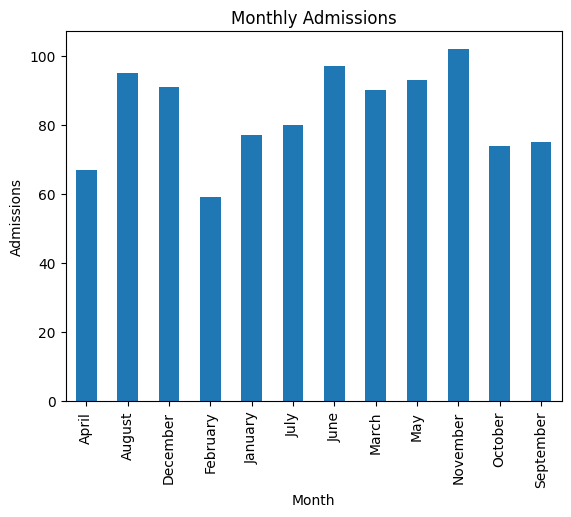

In [19]:
import matplotlib.pyplot as plt

monthly_admissions = df['Month'].value_counts().sort_index()

monthly_admissions.plot(kind='bar')

plt.title("Monthly Admissions")
plt.xlabel("Month")
plt.ylabel("Admissions")
plt.show()

visualisation

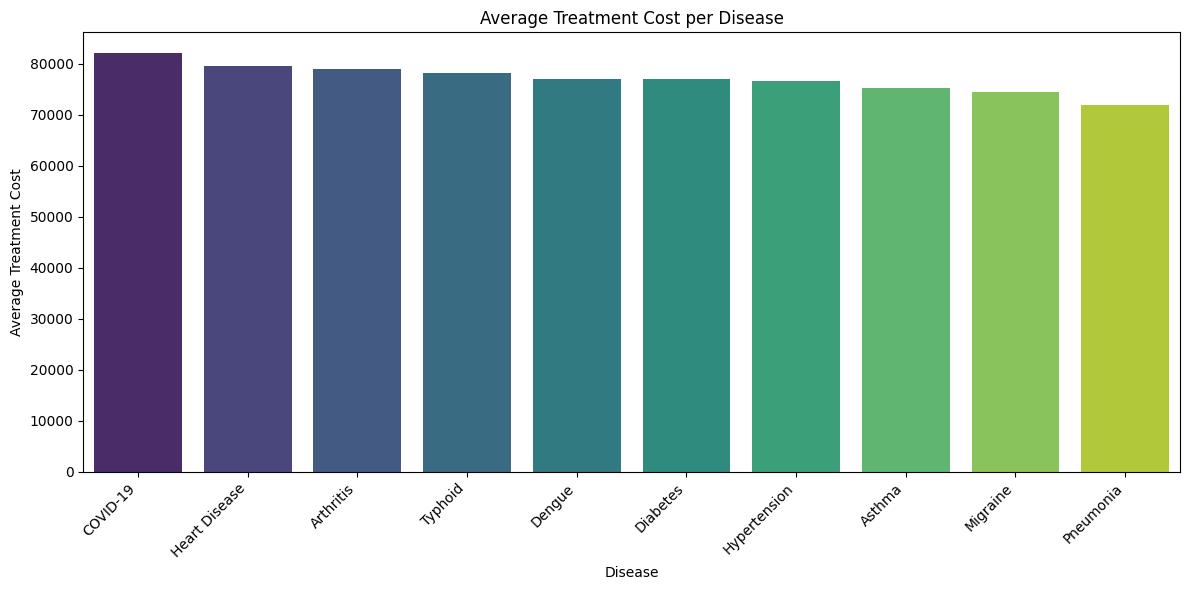

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

average_cost_per_disease = df.groupby('Disease')['Treatment_Cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=average_cost_per_disease.index, y=average_cost_per_disease.values, hue=average_cost_per_disease.index, palette='viridis', legend=False)
plt.title('Average Treatment Cost per Disease')
plt.xlabel('Disease')
plt.ylabel('Average Treatment Cost')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()